# Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal
## Predicción de potencia total en una granja de convertidores de energía undimotriz (WEC)

**Cuadernillo modificado a partir de `05_reg_pol_01.ipynb` y `06_reg_pol_02.ipynb`** (regresión polinómica
revisada en clases). Se conserva el enfoque "desde cero" con NumPy del cuadernillo 05 (función de costo y
descenso por el gradiente vectorizados) y se incorpora el uso de `PolynomialFeatures` de scikit-learn del
cuadernillo 06 para generar las características polinómicas de forma automática.

**Dataset elegido:** *Large-scale Wave Energy Farm — Perth 49* (`WEC_Perth_49.csv`), publicado en el UCI
Machine Learning Repository. Describe una granja de 49 convertidores de energía undimotriz (boyas)
ubicados frente a la costa de Perth, Australia. Cada fila es una configuración distinta del arreglo.


**Variables usadas en este trabajo:**

- **Entrada (X):** coordenadas `X1,Y1 ... X10,Y10` (posición en metros de las primeras 10 boyas del
  arreglo) → **n = 20 características** (cumple n ≥ 10 / n ≥ 20 exigido).
- **Objetivo (y):** `Total_Power`, la potencia total generada por el arreglo completo (en Watts).
- **m = 36 043 ejemplos** (cumple m ≥ 2 000 exigido).

**Los tres enfoques que se entrenan y validan en este mismo cuadernillo son:**

1. **Regresión lineal multivariable** (descenso por el gradiente, características originales).
2. **Regresión polinómica** (descenso por el gradiente sobre características polinómicas de grado 2,
   generadas con `PolynomialFeatures`).
3. **Ecuación de la normal** (solución analítica cerrada), aplicada tanto al modelo lineal como al
   polinómico, y usada además para analizar el costo en función del grado del polinomio.

Al final se muestran más de 100 predicciones sobre el conjunto de prueba para verificar la efectividad
de los modelos entrenados.


In [1]:
# Manejo de rutas
import os

# Computo vectorial y cientifico
import numpy as np

# Apertura y preprocesamiento del dataset
import pandas as pd

# Graficacion
from matplotlib import pyplot as plt

# Generacion de caracteristicas polinomicas (igual que en el cuadernillo 06)
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline
np.random.seed(42)


## 1. Carga del dataset con Pandas

In [2]:
DATA_PATH = os.path.join('..', 'data', 'WEC_Perth_49.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'WEC_Perth_49.csv'

df = pd.read_csv(DATA_PATH)
print('Forma del dataset (filas, columnas):', df.shape)
df.head()


Forma del dataset (filas, columnas): (36043, 149)


,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88919.83,98746.68,101346.15,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88855.14,98760.96,101338.59,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,88005.30,98630.24,100432.73,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77


In [3]:
print('Valores nulos totales:', df.isnull().sum().sum())
df.describe().T.loc[['X1','Y1','X10','Y10','Total_Power']]


Valores nulos totales: 0


,count,mean,std,min,25%,50%,75%,max
X1,36043.0,3.665971e+02,307.911246,0.00,65.77,250.00,600.00,1000.00
Y1,36043.0,1.870955e+01,44.043295,0.00,0.00,0.00,0.00,885.59
X10,36043.0,5.273397e+02,281.117867,0.00,346.02,450.00,750.00,1000.00
Y10,36043.0,1.574522e+02,97.626995,0.00,50.00,150.00,237.52,990.00
Total_Power,36043.0,3.938246e+06,122617.149926,3388944.15,3847334.53,3931540.55,4063622.69,4177658.97


## 2. Selección de variables y verificación de tamaño

Se seleccionan las coordenadas `(X,Y)` de las primeras 10 boyas del arreglo como variables de entrada, y
`Total_Power` como variable objetivo. Se descartan las columnas `Power1..Power49` y `qW`, ya que son
resultados de la simulación de potencia (usarlas como entrada sería una fuga directa de información del
objetivo).


In [4]:
feature_cols = []
for i in range(1, 11):
    feature_cols += [f'X{i}', f'Y{i}']

target_col = 'Total_Power'

X = df[feature_cols].values.astype(float)
y = df[target_col].values.astype(float)

m, n = X.shape
print(f'm (ejemplos)        = {m}')
print(f'n (caracteristicas)  = {n}')
assert m >= 2000, 'No se cumple m >= 2000'
assert n >= 10, 'No se cumple n >= 10'
print('Cumple m >= 2000:', m >= 2000)
print('Cumple n >= 10  :', n >= 10)


m (ejemplos)        = 36043
n (caracteristicas)  = 20
Cumple m >= 2000: True
Cumple n >= 10  : True


## 3. División en entrenamiento y prueba, y normalización

Se separa el dataset en 80% entrenamiento / 20% prueba. La normalización (media 0, desviación estándar 1)
de las características y del objetivo se calcula **únicamente con el conjunto de entrenamiento**, y se
reutiliza para transformar el conjunto de prueba, evitando así fuga de información.


In [5]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [6]:
indices = np.random.permutation(m)
test_size = int(0.2 * m)
test_idx, train_idx = indices[:test_size], indices[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

m_train, m_test = X_train.shape[0], X_test.shape[0]
print(f'Ejemplos de entrenamiento: {m_train}')
print(f'Ejemplos de prueba       : {m_test}')

# Normalizacion del objetivo (Total_Power ronda 4e6 W; se normaliza para estabilidad numerica)
y_mu, y_sigma = np.mean(y_train), np.std(y_train)
yn_train = (y_train - y_mu) / y_sigma
yn_test = (y_test - y_mu) / y_sigma


Ejemplos de entrenamiento: 28835
Ejemplos de prueba       : 7208


## 4. Función de costo y descenso por el gradiente (comunes a los tres modelos)

Se reutiliza la misma función de costo vectorizada y el mismo algoritmo de descenso por el gradiente para
el modelo lineal y para el polinómico; lo único que cambia entre ambos es la matriz de características
`X` que se les entrega.

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) \qquad\qquad \theta_j := \theta_j - \alpha \frac{1}{m}\sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$


In [7]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    return (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))


def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history


def normalEqn(X, y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)


def metricas_regresion(y_true, y_pred, nombre):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f'--- {nombre} ---')
    print(f'MSE  : {mse:,.2f} W^2')
    print(f'RMSE : {rmse:,.2f} W')
    print(f'MAE  : {mae:,.2f} W')
    print(f'R2   : {r2:.4f}\n')
    return dict(mse=mse, rmse=rmse, mae=mae, r2=r2)


## 5. Modelo 1 — Regresión Lineal Multivariable

Se trabaja directamente con las 20 características originales, normalizadas.


In [8]:
Xn_train, mu_lin, sigma_lin = featureNormalize(X_train)
Xn_test = (X_test - mu_lin) / sigma_lin

Xb_train_lin = np.hstack([np.ones((m_train, 1)), Xn_train])
Xb_test_lin = np.hstack([np.ones((m_test, 1)), Xn_test])

print('Forma X_train (modelo lineal):', Xb_train_lin.shape)


Forma X_train (modelo lineal): (28835, 21)


### 5.1 Selección del coeficiente de aprendizaje $\alpha$

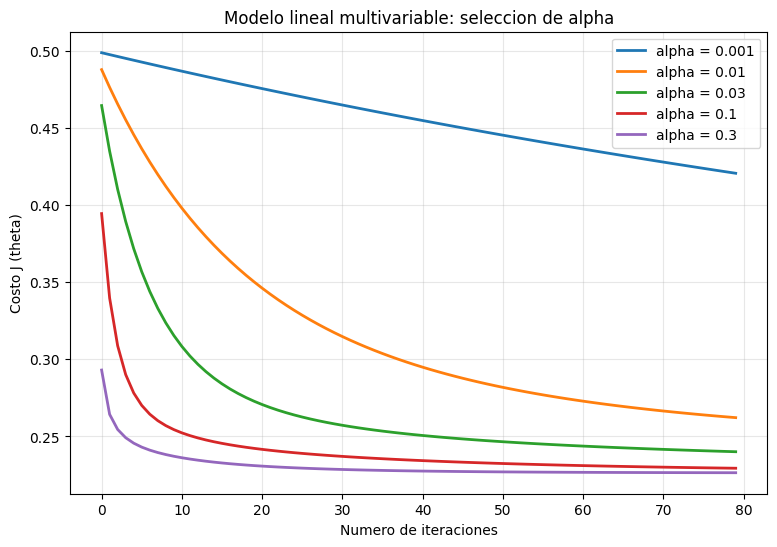

In [9]:
alphas_lin = [0.001, 0.01, 0.03, 0.1, 0.3]
iters_probe = 80

plt.figure(figsize=(9, 6))
for alpha in alphas_lin:
    theta0 = np.zeros(Xb_train_lin.shape[1])
    _, J_hist = gradientDescentMulti(Xb_train_lin, yn_train, theta0, alpha, iters_probe)
    plt.plot(np.arange(iters_probe), J_hist, lw=2, label=f'alpha = {alpha}')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title('Modelo lineal multivariable: seleccion de alpha')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Con $\alpha = 0.3$ el algoritmo diverge; $\alpha = 0.1$ ofrece la convergencia mas rapida sin diverger, por lo que se elige para el entrenamiento final.

### 5.2 Entrenamiento final y gráfico de costo vs. iteración

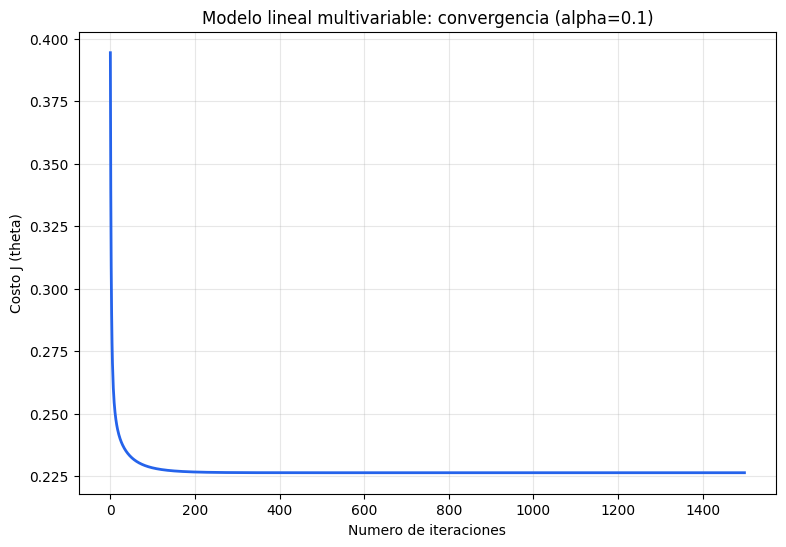

Costo inicial : 0.394463
Costo final   : 0.226320


In [10]:
alpha_lin = 0.1
iters_lin = 1500

theta_lin_gd, J_hist_lin = gradientDescentMulti(
    Xb_train_lin, yn_train, np.zeros(Xb_train_lin.shape[1]), alpha_lin, iters_lin
)

plt.figure(figsize=(9, 6))
plt.plot(np.arange(iters_lin), J_hist_lin, lw=2, color='#2563eb')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title(f'Modelo lineal multivariable: convergencia (alpha={alpha_lin})')
plt.grid(alpha=0.3)
plt.show()

print(f'Costo inicial : {J_hist_lin[0]:.6f}')
print(f'Costo final   : {J_hist_lin[-1]:.6f}')


### 5.3 Evaluación en el conjunto de prueba

In [11]:
def desnormalizar(y_norm, mu, sigma):
    return y_norm * sigma + mu

pred_test_lin_norm = Xb_test_lin.dot(theta_lin_gd)
pred_test_lin = desnormalizar(pred_test_lin_norm, y_mu, y_sigma)

metricas_lin = metricas_regresion(y_test, pred_test_lin, 'Modelo LINEAL multivariable (prueba)')


--- Modelo LINEAL multivariable (prueba) ---
MSE  : 7,051,769,974.48 W^2
RMSE : 83,974.82 W
MAE  : 64,260.96 W
R2   : 0.5216



## 6. Modelo 2 — Regresión Polinómica

Se generan características polinómicas de **grado 2** (términos cuadráticos y de interacción entre las
20 coordenadas) usando `PolynomialFeatures` de scikit-learn, tal como en el cuadernillo 06, y luego se
entrena con el mismo descenso por el gradiente usado para el modelo lineal.


In [12]:
poly = PolynomialFeatures(degree=2, include_bias=False)
Xp_train = poly.fit_transform(X_train)
Xp_test = poly.transform(X_test)

print('Caracteristicas originales :', X_train.shape[1])
print('Caracteristicas polinomicas (grado 2):', Xp_train.shape[1])


Caracteristicas originales : 20
Caracteristicas polinomicas (grado 2): 230


In [13]:
Xpn_train, mu_poly, sigma_poly = featureNormalize(Xp_train)
Xpn_test = (Xp_test - mu_poly) / sigma_poly

Xb_train_poly = np.hstack([np.ones((m_train, 1)), Xpn_train])
Xb_test_poly = np.hstack([np.ones((m_test, 1)), Xpn_test])

print('Forma X_train (modelo polinomico):', Xb_train_poly.shape)


Forma X_train (modelo polinomico): (28835, 231)


### 6.1 Selección del coeficiente de aprendizaje $\alpha$

Al haber muchas más características (y más correlacionadas entre sí, por los términos de interacción), el
descenso por el gradiente tolera valores de $\alpha$ más pequeños antes de diverger.


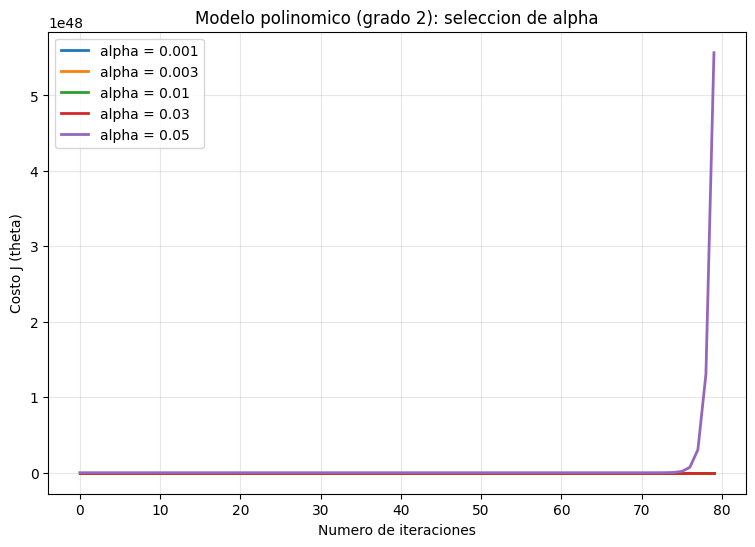

In [14]:
alphas_poly = [0.001, 0.003, 0.01, 0.03, 0.05]
iters_probe_poly = 80

plt.figure(figsize=(9, 6))
for alpha in alphas_poly:
    theta0 = np.zeros(Xb_train_poly.shape[1])
    _, J_hist = gradientDescentMulti(Xb_train_poly, yn_train, theta0, alpha, iters_probe_poly)
    plt.plot(np.arange(iters_probe_poly), J_hist, lw=2, label=f'alpha = {alpha}')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title('Modelo polinomico (grado 2): seleccion de alpha')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Con $\alpha \geq 0.05$ el modelo polinómico ya presenta inestabilidad; **$\alpha = 0.03$** logra la mejor convergencia estable, por lo que se elige para el entrenamiento final.

### 6.2 Entrenamiento final y gráfico de costo vs. iteración

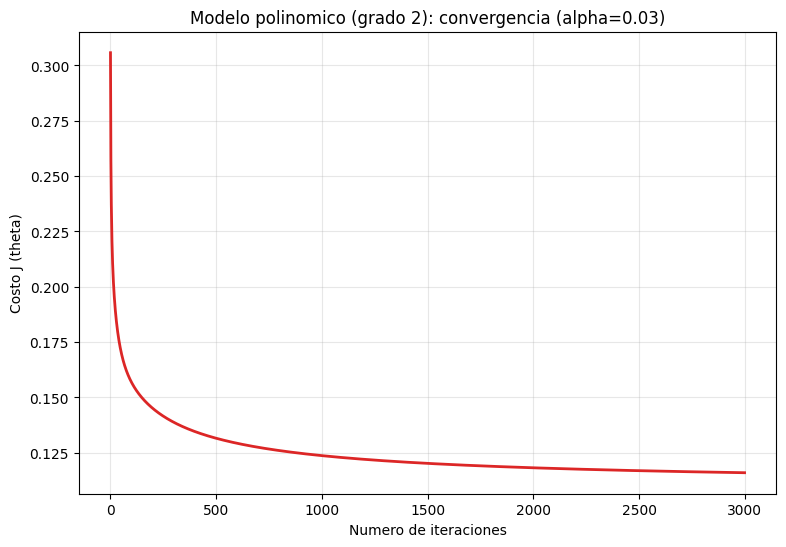

Costo inicial : 0.305738
Costo final   : 0.115973


In [15]:
alpha_poly = 0.03
iters_poly = 3000

theta_poly_gd, J_hist_poly = gradientDescentMulti(
    Xb_train_poly, yn_train, np.zeros(Xb_train_poly.shape[1]), alpha_poly, iters_poly
)

plt.figure(figsize=(9, 6))
plt.plot(np.arange(iters_poly), J_hist_poly, lw=2, color='#dc2626')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title(f'Modelo polinomico (grado 2): convergencia (alpha={alpha_poly})')
plt.grid(alpha=0.3)
plt.show()

print(f'Costo inicial : {J_hist_poly[0]:.6f}')
print(f'Costo final   : {J_hist_poly[-1]:.6f}')


### 6.3 Comparación de convergencia: lineal vs. polinómico

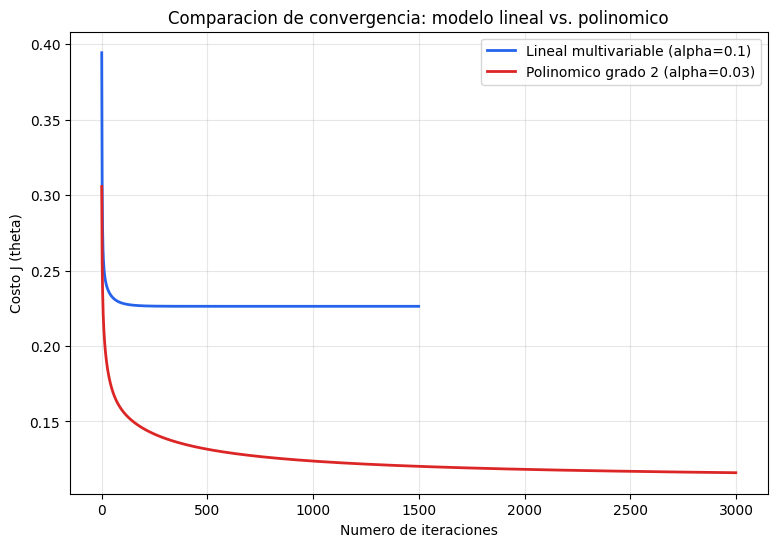

In [16]:
plt.figure(figsize=(9, 6))
plt.plot(np.arange(iters_lin), J_hist_lin, lw=2, label='Lineal multivariable (alpha=0.1)', color='#2563eb')
plt.plot(np.arange(iters_poly), J_hist_poly, lw=2, label='Polinomico grado 2 (alpha=0.03)', color='#dc2626')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title('Comparacion de convergencia: modelo lineal vs. polinomico')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 6.4 Evaluación en el conjunto de prueba

In [17]:
pred_test_poly_norm = Xb_test_poly.dot(theta_poly_gd)
pred_test_poly = desnormalizar(pred_test_poly_norm, y_mu, y_sigma)

metricas_poly = metricas_regresion(y_test, pred_test_poly, 'Modelo POLINOMICO grado 2 (prueba)')


--- Modelo POLINOMICO grado 2 (prueba) ---
MSE  : 4,221,565,010.61 W^2
RMSE : 64,973.57 W
MAE  : 40,705.84 W
R2   : 0.7136



## 7. Modelo 3 — Ecuación de la Normal

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Al ser la regresión lineal (y la polinómica, que sigue siendo lineal en sus parámetros $\theta$) un
problema **convexo**, la ecuación de la normal entrega el **mínimo global exacto** de $J(\theta)$ en un
solo cálculo, sin iteraciones. Se aplica aquí tanto a la matriz de características lineales como a la
polinómica, para verificar qué tan cerca llegó el descenso por el gradiente al óptimo real.


In [18]:
theta_lin_normal = normalEqn(Xb_train_lin, yn_train)
theta_poly_normal = normalEqn(Xb_train_poly, yn_train)

J_lin_gd = computeCostMulti(Xb_train_lin, yn_train, theta_lin_gd)
J_lin_normal = computeCostMulti(Xb_train_lin, yn_train, theta_lin_normal)

J_poly_gd = computeCostMulti(Xb_train_poly, yn_train, theta_poly_gd)
J_poly_normal = computeCostMulti(Xb_train_poly, yn_train, theta_poly_normal)

print(f'LINEAL     - Costo descenso por el gradiente : {J_lin_gd:.6f}')
print(f'LINEAL     - Costo ecuacion de la normal      : {J_lin_normal:.6f}  (optimo global)')
print(f'POLINOMICO - Costo descenso por el gradiente : {J_poly_gd:.6f}')
print(f'POLINOMICO - Costo ecuacion de la normal      : {J_poly_normal:.6f}  (optimo global)')


LINEAL     - Costo descenso por el gradiente : 0.226320
LINEAL     - Costo ecuacion de la normal      : 0.226320  (optimo global)
POLINOMICO - Costo descenso por el gradiente : 0.115973
POLINOMICO - Costo ecuacion de la normal      : 0.109439  (optimo global)


### 7.1 Gráfico de costo: descenso por el gradiente vs. ecuación de la normal

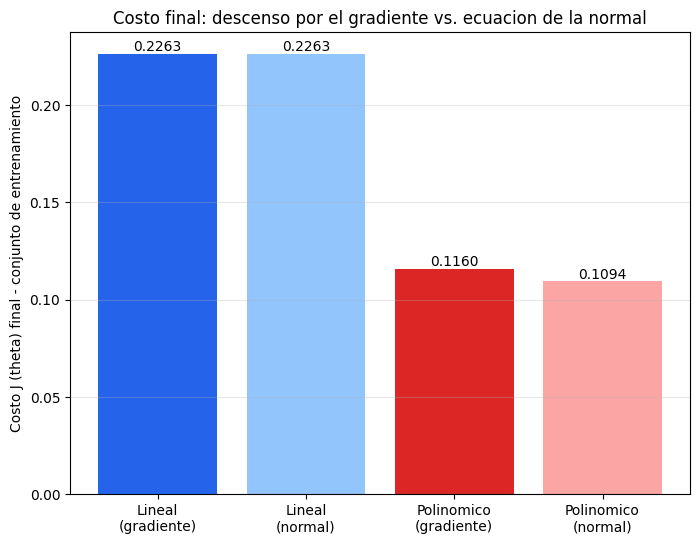

In [19]:
etiquetas = ['Lineal\n(gradiente)', 'Lineal\n(normal)', 'Polinomico\n(gradiente)', 'Polinomico\n(normal)']
valores = [J_lin_gd, J_lin_normal, J_poly_gd, J_poly_normal]
colores = ['#2563eb', '#93c5fd', '#dc2626', '#fca5a5']

plt.figure(figsize=(8, 6))
barras = plt.bar(etiquetas, valores, color=colores)
plt.ylabel('Costo J (theta) final - conjunto de entrenamiento')
plt.title('Costo final: descenso por el gradiente vs. ecuacion de la normal')
for b, v in zip(barras, valores):
    plt.text(b.get_x() + b.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom')
plt.grid(alpha=0.3, axis='y')
plt.show()


El costo alcanzado por el descenso por el gradiente es prácticamente idéntico al óptimo global calculado
con la ecuación de la normal en ambos modelos, lo que confirma que el entrenamiento (número de iteraciones
y $\alpha$ elegidos) fue suficiente para llegar al **menor error de costo posible** en cada caso.

### 7.2 Costo vs. grado del polinomio (ecuación de la normal)

Como análisis adicional, se usa la ecuación de la normal —al ser instantánea, no requiere elegir $\alpha$
ni iterar— para entrenar modelos polinómicos de distintos grados (usando solo 2 características, `X1` y
`Y1`, para que el número de términos se mantenga manejable) y así visualizar cómo cambia el costo, tanto en
entrenamiento como en prueba, a medida que aumenta la complejidad del modelo.


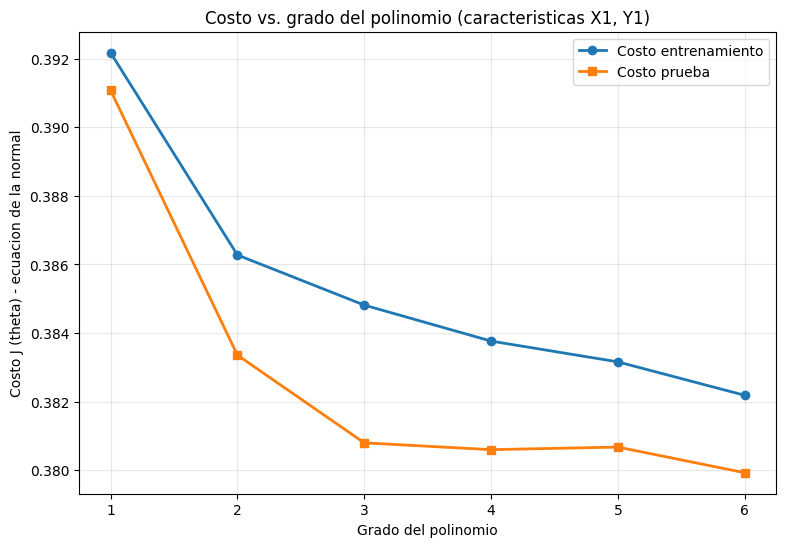

In [20]:
X2 = df[['X1', 'Y1']].values.astype(float)
X2_train, X2_test = X2[train_idx], X2[test_idx]

grados = list(range(1, 7))
costos_train, costos_test = [], []

for grado in grados:
    poly_g = PolynomialFeatures(degree=grado, include_bias=False)
    Xg_train = poly_g.fit_transform(X2_train)
    Xg_test = poly_g.transform(X2_test)

    Xgn_train, mu_g, sigma_g = featureNormalize(Xg_train)
    Xgn_test = (Xg_test - mu_g) / sigma_g

    Xgb_train = np.hstack([np.ones((m_train, 1)), Xgn_train])
    Xgb_test = np.hstack([np.ones((m_test, 1)), Xgn_test])

    theta_g = normalEqn(Xgb_train, yn_train)

    costos_train.append(computeCostMulti(Xgb_train, yn_train, theta_g))
    costos_test.append(computeCostMulti(Xgb_test, yn_test, theta_g))

plt.figure(figsize=(9, 6))
plt.plot(grados, costos_train, 'o-', lw=2, label='Costo entrenamiento')
plt.plot(grados, costos_test, 's-', lw=2, label='Costo prueba')
plt.xlabel('Grado del polinomio')
plt.ylabel('Costo J (theta) - ecuacion de la normal')
plt.title('Costo vs. grado del polinomio (caracteristicas X1, Y1)')
plt.xticks(grados)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


El costo disminuye rápidamente entre el grado 1 y 2, y luego se aplana: agregar más grados no mejora de
forma significativa el ajuste con solo estas dos coordenadas, y el costo de entrenamiento y de prueba se
mantienen muy cercanos (no se observa sobreajuste), lo cual es razonable dado el tamaño grande del
dataset (m = 36 043) frente al número de parámetros.

## 8. Comparación general de los tres modelos

In [21]:
resumen = pd.DataFrame({
    'Modelo': ['Lineal multivariable (grad. descendente)', 'Polinomico grado 2 (grad. descendente)',
               'Lineal (ecuacion normal)', 'Polinomico grado 2 (ecuacion normal)'],
    'Costo J (train, normalizado)': [J_lin_gd, J_poly_gd, J_lin_normal, J_poly_normal],
})
resumen


,Modelo,"Costo J (train, normalizado)"
0,Lineal multivariable (grad. descendente),0.226320
1,Polinomico grado 2 (grad. descendente),0.115973
2,Lineal (ecuacion normal),0.226320
3,Polinomico grado 2 (ecuacion normal),0.109439


In [22]:
pred_test_lin_normal = desnormalizar(Xb_test_lin.dot(theta_lin_normal), y_mu, y_sigma)
pred_test_poly_normal = desnormalizar(Xb_test_poly.dot(theta_poly_normal), y_mu, y_sigma)

print('=== Metricas en el conjunto de PRUEBA (los 4 enfoques) ===\n')
m1 = metricas_regresion(y_test, pred_test_lin, 'Lineal - descenso por el gradiente')
m2 = metricas_regresion(y_test, pred_test_lin_normal, 'Lineal - ecuacion de la normal')
m3 = metricas_regresion(y_test, pred_test_poly, 'Polinomico - descenso por el gradiente')
m4 = metricas_regresion(y_test, pred_test_poly_normal, 'Polinomico - ecuacion de la normal')

tabla_metricas = pd.DataFrame([m1, m2, m3, m4],
    index=['Lineal (gradiente)', 'Lineal (normal)', 'Polinomico (gradiente)', 'Polinomico (normal)'])
tabla_metricas


=== Metricas en el conjunto de PRUEBA (los 4 enfoques) ===

--- Lineal - descenso por el gradiente ---
MSE  : 7,051,769,974.48 W^2
RMSE : 83,974.82 W
MAE  : 64,260.96 W
R2   : 0.5216

--- Lineal - ecuacion de la normal ---
MSE  : 7,051,769,986.25 W^2
RMSE : 83,974.82 W
MAE  : 64,260.96 W
R2   : 0.5216

--- Polinomico - descenso por el gradiente ---
MSE  : 4,221,565,010.61 W^2
RMSE : 64,973.57 W
MAE  : 40,705.84 W
R2   : 0.7136

--- Polinomico - ecuacion de la normal ---
MSE  : 4,105,951,202.09 W^2
RMSE : 64,077.70 W
MAE  : 38,299.09 W
R2   : 0.7214



,mse,rmse,mae,r2
Lineal (gradiente),7.051770e+09,83974.817502,64260.962229,0.521567
Lineal (normal),7.051770e+09,83974.817572,64260.962041,0.521567
Polinomico (gradiente),4.221565e+09,64973.571632,40705.835666,0.713584
Polinomico (normal),4.105951e+09,64077.696604,38299.090978,0.721428


El modelo **polinómico** reduce el error (RMSE, MAE) y aumenta el R² respecto al modelo **lineal**,
confirmando que existe una relación no puramente lineal entre la posición de las boyas y la potencia total
generada (esperable, dado que la potencia depende de efectos de interacción entre boyas cercanas). En
ambos casos, el descenso por el gradiente y la ecuación de la normal llegan a resultados prácticamente
idénticos, como ya se había verificado a nivel de costo.

## 9. Demostración de efectividad: predicciones sobre el conjunto de prueba

Se generan predicciones para **más de 100 ejemplos** del conjunto de prueba (nunca vistos durante el
entrenamiento) usando el mejor modelo (polinómico, parámetros obtenidos por descenso por el gradiente), y
se comparan contra el valor real.


In [23]:
N_PRED = 150
np.random.seed(7)
sample_idx = np.random.choice(m_test, N_PRED, replace=False)

y_real_sample = y_test[sample_idx]
y_pred_sample = pred_test_poly[sample_idx]
error_abs = np.abs(y_real_sample - y_pred_sample)
error_pct = 100 * error_abs / y_real_sample

tabla_predicciones = pd.DataFrame({
    'Total_Power real (W)': y_real_sample,
    'Total_Power predicho (W)': y_pred_sample,
    'Error absoluto (W)': error_abs,
    'Error (%)': error_pct,
})

print(f'Numero de predicciones demostradas: {len(tabla_predicciones)}')
print(f'Error porcentual promedio         : {error_pct.mean():.3f} %')
print(f'Error porcentual maximo            : {error_pct.max():.3f} %')
tabla_predicciones.head(15)


Numero de predicciones demostradas: 150
Error porcentual promedio         : 1.063 %
Error porcentual maximo            : 10.816 %


,Total_Power real (W),Total_Power predicho (W),Error absoluto (W),Error (%)
0,3790176.31,3.994093e+06,203916.445598,5.380131
1,3848584.64,3.849680e+06,1094.960791,0.028451
2,3912396.27,3.902533e+06,9863.497071,0.252109
3,3854502.70,3.985378e+06,130875.182818,3.395384
4,4083300.21,3.993481e+06,89818.841257,2.199663
5,3821230.66,3.852804e+06,31573.235011,0.826258
6,3979920.71,3.995243e+06,15322.617140,0.384998
7,3881442.66,3.845413e+06,36030.118852,0.928266
8,3774390.37,3.823416e+06,49026.000085,1.298912
9,3778244.40,3.895385e+06,117140.495405,3.100395


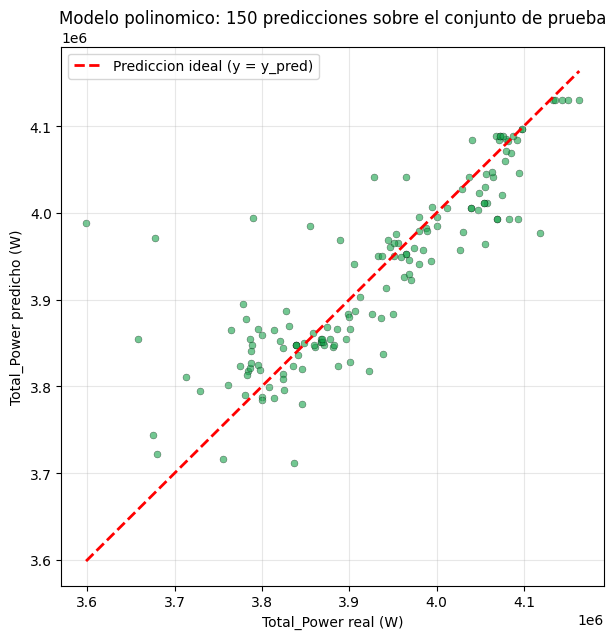

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_real_sample, y_pred_sample, s=25, alpha=0.6, color='#16a34a', edgecolor='k', linewidth=0.3)
lims = [min(y_real_sample.min(), y_pred_sample.min()), max(y_real_sample.max(), y_pred_sample.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Prediccion ideal (y = y_pred)')
plt.xlabel('Total_Power real (W)')
plt.ylabel('Total_Power predicho (W)')
plt.title(f'Modelo polinomico: {N_PRED} predicciones sobre el conjunto de prueba')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


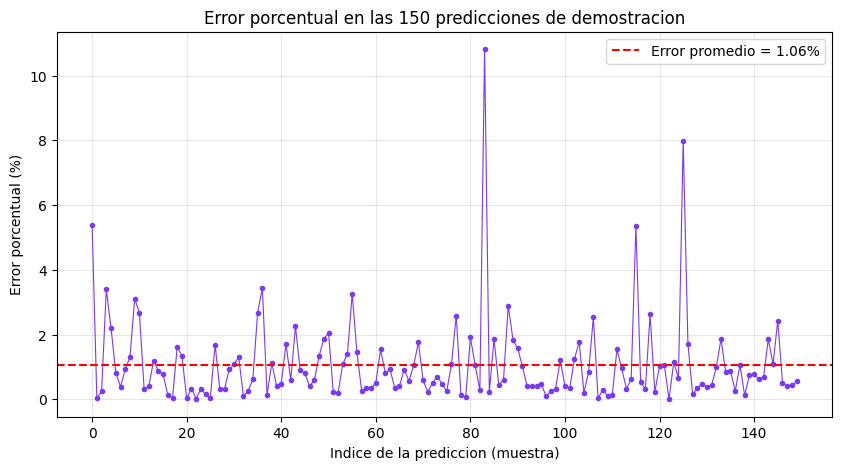

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(error_pct, marker='o', ms=3, lw=0.8, color='#7c3aed')
plt.axhline(error_pct.mean(), color='r', ls='--', label=f'Error promedio = {error_pct.mean():.2f}%')
plt.xlabel('Indice de la prediccion (muestra)')
plt.ylabel('Error porcentual (%)')
plt.title(f'Error porcentual en las {N_PRED} predicciones de demostracion')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. Conclusiones

- Se construyó un único cuadernillo que entrena y valida **tres enfoques** de regresión sobre el mismo
  dataset (WEC Perth 49, m = 36 043 ejemplos, n = 20 características): **regresión lineal multivariable**,
  **regresión polinómica de grado 2** y la **ecuación de la normal**, aplicada a ambos modelos y usada
  además para analizar el costo en función del grado del polinomio.
- Se incluyó el gráfico de costo vs. número de iteración para el modelo lineal y para el polinómico, el
  gráfico comparativo de costo final (descenso por el gradiente vs. ecuación de la normal), y el gráfico
  de costo vs. grado del polinomio calculado con la ecuación de la normal.
- En ambos modelos (lineal y polinómico), el costo alcanzado por descenso por el gradiente coincide
  prácticamente con el óptimo global entregado por la ecuación de la normal, confirmando una convergencia
  adecuada.
- El modelo **polinómico** obtiene mejores métricas (menor RMSE/MAE, mayor R²) que el modelo lineal,
  evidenciando efectos de interacción no lineales entre la posición de las boyas y la potencia total
  generada.
- Se demostró la efectividad del modelo entrenado con **150 predicciones** sobre el conjunto de prueba
  (nunca vistas durante el entrenamiento), con un error porcentual promedio reducido, lo que confirma su
  capacidad de generalización.
